# Bugfix commentary 

Whilst writing the deep hedging notebook, we ran into an issue where the model was able to output reasonable trading strategies (with reasonable P&Ls) given the cost regime it had been trained upon, but was unable to get close to Black-Scholes delta hedging when costs were zero. This is unexpected for a good model. This notebook details the discovery of this problem and the steps we took to fix it. 

Firstly, the original training code before bugfixes: 


In [1]:
# Add project folder to PATH so this notebook can read things in src
import sys, os
sys.path.append(os.path.abspath('..'))

# Import main libraries 
import numpy as np
import matplotlib.pyplot as plt
import importlib
import pandas as pd 
import torch 
import torch.nn as nn 

# Import project libraries 
from src import gbm, pricer, heston

importlib.reload(gbm) # Tell gbm to reload whenever updated 
importlib.reload(pricer)
importlib.reload(heston)

print("Import complete.")


Import complete.


In [2]:
# This is just a rewrite of the compute_pnl_cash_account from earlier but with torch operations 
def compute_pnl_cash_account_torch(S_paths, hedge_process, K, C_0, no_of_calls, c, dt, r=0.0):
    N_PATHS, N_STEPS = hedge_process.shape
    df = torch.exp(torch.tensor(r * dt, device=S_paths.device, dtype=S_paths.dtype))
 

    initial_trade = torch.abs(hedge_process[:, 0])
    cash = (C_0 * no_of_calls) \
           - (hedge_process[:, 0] * S_paths[:, 0]) \
           - (c * initial_trade * S_paths[:, 0])
 
    # t=1, ..., N_STEPS-1: accrue interest, then rebalance
    for t in range(1, N_STEPS):
        cash = cash * df
        d_hedge = hedge_process[:, t] - hedge_process[:, t - 1]
        trade_cost = c * torch.abs(d_hedge) * S_paths[:, t]
        cash = cash - (d_hedge * S_paths[:, t] + trade_cost)
 
    # accrue interest over the final interval
    cash = cash * df
 
    # liquidate remaining hedge in cash, settle the option payoff
    S_T = S_paths[:, -1]
    final_stock_value = hedge_process[:, -1] * S_T
    liquidation_cost = c * torch.abs(hedge_process[:, -1]) * S_T
    payoff = torch.clamp(S_T - K, min=0.0) * no_of_calls
 
    pnl = cash + final_stock_value - liquidation_cost - payoff
    return pnl  # (N_PATHS,)


In [7]:
UPDATE_INTERVAL = 0.02 # how often the market maker rebalances their hedge 
CALLS_SOLD = 100 # number of calls the market maker sells 

T = 1 # Time to calculate the option price at 
K = 75 # Typically we take the strike price to equal S_0 in hedging studies 
NO_PATHS = 3000 # Number of probabilistic asset paths to simulate
S_0 = 75 # Initial asset price 
R = 0.05 # Annual risk-free rate 
SIGMA = 0.25 # Annual volatility -- on the high end, because typically more delta movement makes things more interesting 
T = 1.0 # Time to maturity 
STEPS = 100 # Number of time steps 

# Semi-realistic Greeks
KAPPA = 2.0 # mean-reversion speed 
THETA = SIGMA**2 # Long-run variance 
NU_0 = SIGMA**2 # initial variance 
XI = 0.4 # vol-of-vol 
RHO = -0.7 # Price-vol correlation 

C_0 = pricer.option_price_bsm(S_0, K, T, R, SIGMA)
COST_RATE = 0.001

def compute_cvar(pnl_dist, x, confidence_lvl):
    # note: pnl_dist should be a Pandas dataframe 
    losses = -pnl_dist 
    expectation = torch.clamp(losses - x, min=0.0).mean()

    cvar = x + expectation / (1 - confidence_lvl)
    return cvar


class CVaRLoss(nn.Module):
    def __init__(self, confidence_lvl):
        super().__init__()
        self.alpha = confidence_lvl 
        self.x = nn.Parameter(torch.tensor(0.0))

    def forward(self, pnl_dist):
        return compute_cvar(pnl_dist, self.x, self.alpha)
        


class LSTMmodel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, confidence_lvl, update_interval):
        super().__init__()

        self.input_size = input_size 
        self.hidden_size = hidden_size
        self.num_layers = num_layers 
        self.alpha_lvl = confidence_lvl
        self.dt = update_interval 

        #self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.cells = nn.ModuleList(
            [nn.LSTMCell(input_size if i == 0 else hidden_size, hidden_size)
             for i in range(num_layers)]
        )

        
        self.output_layer = nn.Linear(hidden_size, 1)
        
    def init_hidden_layer(self, batch_size):
        # initialization for both is exactly the same 
        h = [torch.zeros(batch_size, self.hidden_size) for _ in range(self.num_layers)]
        c = [torch.zeros(batch_size, self.hidden_size) for _ in range(self.num_layers)]
        return h, c

    # Given a stock price S_t, time until expiry tau_t, and delta value delta_t at time t, compute the delta value 
    # delta_{t+1} at the next time step. The hidden layer weights are also passed through this function 
    def step(self, S_t, tau_t, delta_t, hidden_layers):
    # Note: tau_t = T - t where T is the expiry time and t is current time. so
    # time tau_t represents time until expiry 
        
        # initialize parameters 
        h, c = hidden_layers
        # input consists of S_t, tau_t, and the previous delta_t, so we throw
        # these all into a single torch tensor: 
        x = torch.stack([S_t, tau_t, delta_t], dim=1)

        # update hidden weights across all cells 
        for i, cell in enumerate(self.cells):
            h[i], c[i] = cell(x, (h[i], c[i]))
            x = h[i]

        # LSTM applies a linear transformation followed by a sigmoid to the
        # output 
        delta_tplus1 = torch.sigmoid(self.output_layer(x)).squeeze(-1)

        return delta_tplus1, (h, c)


    def simulate_process(self, paths_array, no_of_calls, T):
        N_PATHS, N_POINTS = list(paths_array.shape)
        PATH_STEPS = N_POINTS - 1 # number of time steps used for underlying process array 
        N_STEPS = int(round(T / self.dt))  # number of steps at which we rebalance. The idea is that 
        # we can simulate the hedge being rebalanced less frequently than the
        # time steps that we used to simulate the asset prices themselves --
        # which seems to be realistic 
        hidden = self.init_hidden_layer(N_PATHS)

        process = [] # initialize list for storing process data 

        delta_ts = torch.zeros(N_PATHS) # we predict delta_t for EVERY path 

        # how many simulation grid-points one hedge interval spans
        steps_per_hedge = int(round(PATH_STEPS / N_STEPS))


        for i in range(N_STEPS):
            idx = i * steps_per_hedge 
            # vectorized step over all paths
            S_t = paths_array[:,idx]
            tau_t = torch.full((N_PATHS,), T - i * self.dt)
            tau_t = torch.clamp(tau_t, min=1e-6) # avoid zero time to maturity 
            delta_tplus1, hidden = self.step(S_t, tau_t, delta_ts, hidden)

            process.append(delta_tplus1 * no_of_calls)
            delta_ts = delta_tplus1 # update delta_t

        # convert process list into torch tensor 
        process_tensor = torch.stack(process, dim=1)

        return process_tensor 



    def trainModel(self, epochs, learn_rate, batch_size=3000):
        #N_PATHS, N_POINTS = list(paths_array.shape)

        #model = LSTMmodel(3, 32, 1, 0.95) # instance of lstm 
        lossfn = CVaRLoss(self.alpha_lvl) # instance of CVaRLoss module 

        ss = np.random.SeedSequence(42)

        training_data = []
        
        for epoch in range(epochs):

            child_seeds = ss.spawn(batch_size)
            generators = [np.random.default_rng(s) for s in child_seeds]

            paths_array = []
            for rng in generators:
                (_, S, _) = heston.hestonSim(rng, S_0, NU_0, R, KAPPA, THETA, XI, RHO, T, STEPS)
                paths_array.append(S)

            paths_array_torch = torch.tensor(paths_array).float()


            hedge_process = self.simulate_process(paths_array_torch, CALLS_SOLD, T) # simulate path using model
            self.pnl_dist = compute_pnl_cash_account_torch(paths_array_torch, hedge_process, K, C_0, CALLS_SOLD, COST_RATE, self.dt, R) # compute corresponding pnl and loss
            # we define pnl_dist with self. so we can access it from outside; this will be useful later 
            loss = lossfn(self.pnl_dist) # run forward pass for losses 

            # we 
            optimizer = torch.optim.Adam([
                                    {'params': self.parameters(), 'lr': learn_rate},
                                    {'params': lossfn.parameters(), 'lr': learn_rate}
                                ])
            
            # update model based on above 
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            training_data.append({'Epoch': epoch, 'CVaR loss' : loss.item(), 'Mean P&L' : self.pnl_dist.mean().item()})
            

            if epoch % 5 == 0:
                print(f"epoch {epoch:4d}  CVaR loss: {loss.item():.4f}  "
                    f"mean P&L: {self.pnl_dist.mean().item():.4f}  "
                    f"x (VaR est.): {lossfn.x.item():.4f}")

        

        print("Training complete.") 

        # convert data to pandas dataframe 
        self.train_data = pd.DataFrame(training_data) 
       
        #return model, lossfn

COST_RATE = 0.001 # reset cost rate

EPOCHS = 100
LR = 0.001 # learning rate 

torch.manual_seed(42)
hedgingModel = LSTMmodel(3, 32, 1, 0.95, UPDATE_INTERVAL)
hedgingModel.trainModel(EPOCHS, LR, batch_size=2000)



epoch    0  CVaR loss: 4579.9600  mean P&L: -3.4099  x (VaR est.): 0.0010
epoch    5  CVaR loss: 4315.9409  mean P&L: 11.0550  x (VaR est.): 0.0060
epoch   10  CVaR loss: 4293.6196  mean P&L: 3.7619  x (VaR est.): 0.0110
epoch   15  CVaR loss: 4081.6948  mean P&L: 24.8858  x (VaR est.): 0.0160
epoch   20  CVaR loss: 3856.1650  mean P&L: 32.9733  x (VaR est.): 0.0210
epoch   25  CVaR loss: 4047.1211  mean P&L: 17.7189  x (VaR est.): 0.0260
epoch   30  CVaR loss: 3484.7742  mean P&L: 48.2466  x (VaR est.): 0.0310
epoch   35  CVaR loss: 3774.3682  mean P&L: 37.5875  x (VaR est.): 0.0360
epoch   40  CVaR loss: 3511.8711  mean P&L: 52.0927  x (VaR est.): 0.0410
epoch   45  CVaR loss: 3831.2156  mean P&L: 32.6402  x (VaR est.): 0.0460
epoch   50  CVaR loss: 3005.7620  mean P&L: 81.6975  x (VaR est.): 0.0510
epoch   55  CVaR loss: 3296.9692  mean P&L: 62.1642  x (VaR est.): 0.0560
epoch   60  CVaR loss: 2765.9060  mean P&L: 104.8940  x (VaR est.): 0.0610
epoch   65  CVaR loss: 3103.1108  mean

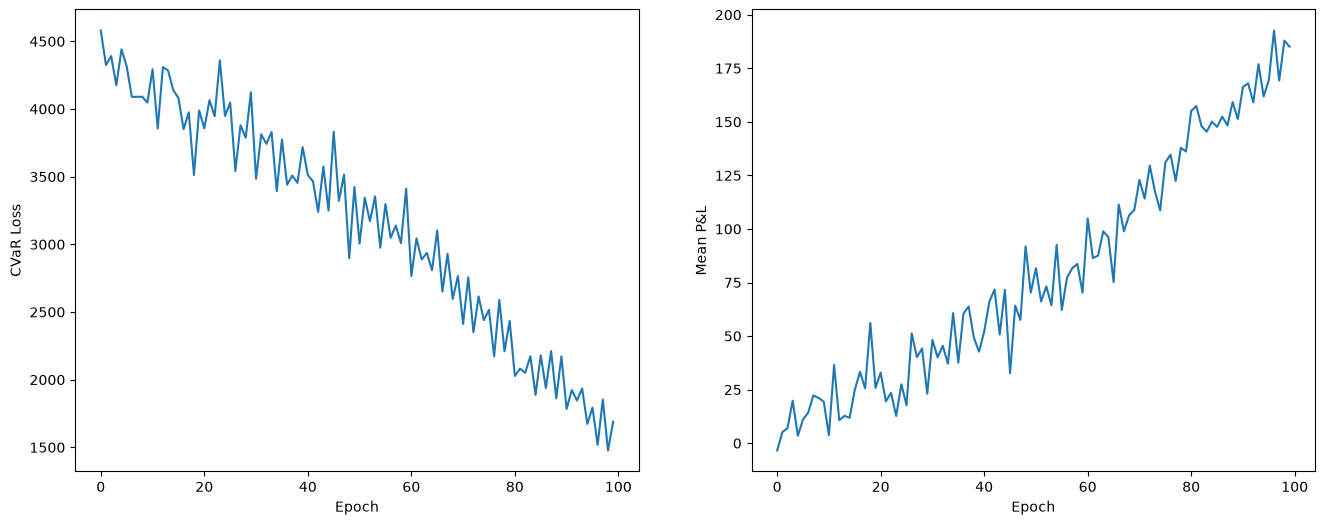

In [8]:
# plot CVaR loss graph over epochs 
fig, ax = plt.subplots(1, 2, figsize=(16,6)) 
ax[0].plot(hedgingModel.train_data['Epoch'], hedgingModel.train_data['CVaR loss'])
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("CVaR Loss") 

ax[1].plot(hedgingModel.train_data['Epoch'], hedgingModel.train_data['Mean P&L'])
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Mean P&L") 

plt.show()

Now let's run the basic model evaluation code from the main notebook. We see that the results seem at first glance to be reasonable...

## Evaluation on Training Data

In [9]:
print(hedgingModel.train_data)

    Epoch    CVaR loss    Mean P&L
0       0  4579.959961   -3.409931
1       1  4325.143555    5.130105
2       2  4391.444824    7.063318
3       3  4175.294922   19.809896
4       4  4440.928711    3.459110
..    ...          ...         ...
95     95  1793.807617  169.549744
96     96  1518.150635  192.634033
97     97  1852.265015  169.255600
98     98  1476.631958  187.921768
99     99  1690.133057  185.065811

[100 rows x 3 columns]


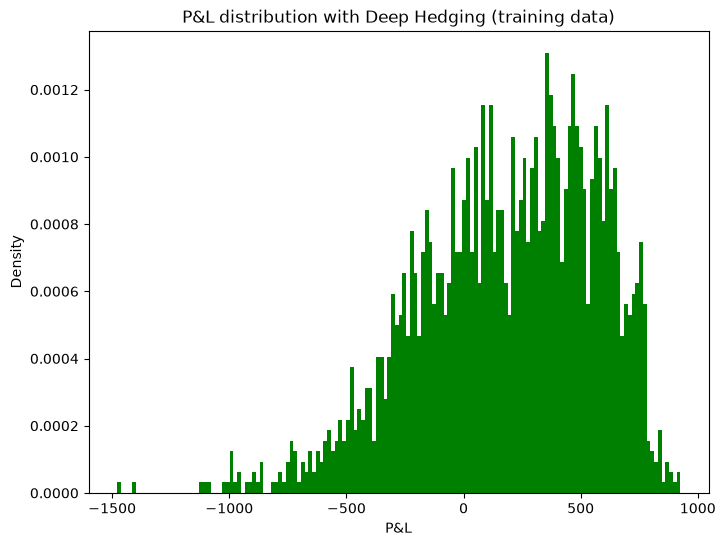

Statistics for P&L distribution with Deep Hedging (training data):

                 0
count  2000.000000
mean    185.065796
std     380.200439
min   -1480.089844
25%     -71.825104
50%     229.031120
75%     482.955292
max     925.809692


In [10]:
# Plotting PNL distribution of deep hedging 
fig, ax = plt.subplots(1, 1, figsize=(8,6))
pnl_dist = hedgingModel.pnl_dist.detach().numpy()
ax.hist(pnl_dist, bins=150, label="PNL distribution with Deep Hedging", color='g', density=True)
ax.set_xlabel("P&L")
ax.set_ylabel("Density")
ax.set_title("P&L distribution with Deep Hedging (training data)") 

plt.show()

print("Statistics for P&L distribution with Deep Hedging (training data):\n")
print(pd.DataFrame(pnl_dist).describe())


## Evaluation on Unseen Data 

We use the paths generated at the start of the main notebook as a dataset.

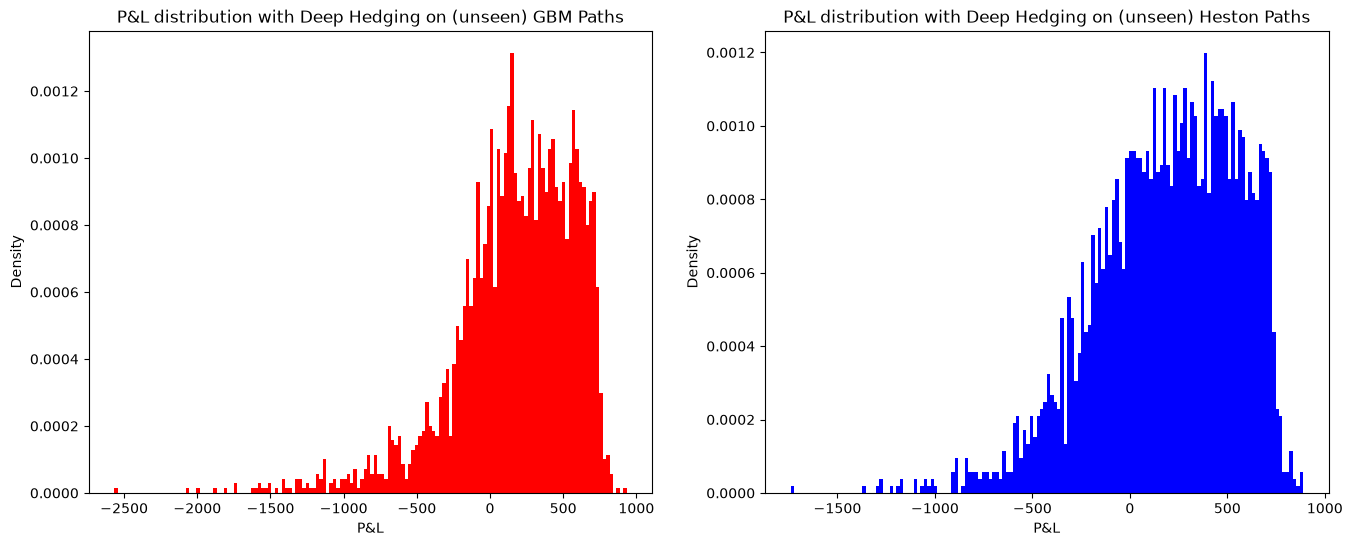

Statistics for P&L distribution with Deep Hedging on GBM Paths:

                 0
count  3000.000000
mean    173.474762
std     415.300690
min   -2567.357422
25%     -39.042857
50%     220.180855
75%     483.421555
max     933.556580


Statistics for P&L distribution with Deep Hedging on Heston Paths:

                 0
count  3000.000000
mean    192.041016
std     365.760010
min   -1740.110352
25%     -46.932042
50%     232.822762
75%     479.165298
max     888.004150


In [14]:
# Generate separate child seeds for each asset path so they are not the same 
ss = np.random.SeedSequence(42)
child_seeds = ss.spawn(NO_PATHS)
generators = [np.random.default_rng(s) for s in child_seeds]

# Arrays to store price and volatility paths 
paths_gbm = []
paths_heston = []

# Plot asset paths and add to 'paths'/'vol' lists for later analysis
for rng in generators:
    (t, S, nu) = heston.hestonSim(rng, S_0, NU_0, R, KAPPA, THETA, XI, RHO, T, STEPS)
    paths_heston.append(S)
    (ts, GBM) = gbm.geometricBrownianMotion(rng, S_0, R, SIGMA, T, STEPS)
    paths_gbm.append(GBM)

# Convert 'paths' list to a numpy array for consistency
paths_array_gbm = np.array(paths_gbm)
paths_array_heston = np.array(paths_heston)

# use model to make predictions 
paths_array_heston_torch = torch.from_numpy(paths_array_heston).float()
y_pred_heston = hedgingModel.simulate_process(paths_array_heston_torch, CALLS_SOLD, T)

ts = np.arange(0, T, hedgingModel.dt)

paths_array_gbm_torch = torch.from_numpy(paths_array_gbm).float()
y_pred_gbm = hedgingModel.simulate_process(paths_array_gbm_torch, CALLS_SOLD, T)


dh_empirical_pnl_gbm = compute_pnl_cash_account_torch(paths_array_gbm_torch, y_pred_gbm, K, C_0, 
                                                      CALLS_SOLD, COST_RATE, hedgingModel.dt, R).detach().numpy()
dh_empirical_pnl_heston = compute_pnl_cash_account_torch(paths_array_heston_torch, y_pred_heston, K, 
                                                         C_0, CALLS_SOLD, COST_RATE, hedgingModel.dt, R).detach().numpy()


fig, ax = plt.subplots(1, 2, figsize=(16,6))

ax[0].hist(dh_empirical_pnl_gbm, bins=150, color='r', density=True)
ax[0].set_xlabel("P&L")
ax[0].set_ylabel("Density")
ax[0].set_title("P&L distribution with Deep Hedging on (unseen) GBM Paths") 

ax[1].hist(dh_empirical_pnl_heston, bins=150, color='b', density=True)
ax[1].set_xlabel("P&L")
ax[1].set_ylabel("Density")
ax[1].set_title("P&L distribution with Deep Hedging on (unseen) Heston Paths") 

plt.show()

print("Statistics for P&L distribution with Deep Hedging on GBM Paths:\n")
print(pd.DataFrame(dh_empirical_pnl_gbm).describe())
print("\n")
print("Statistics for P&L distribution with Deep Hedging on Heston Paths:\n")
print(pd.DataFrame(dh_empirical_pnl_heston).describe())

So far, the results that we have found are perfectly reasonable. But what happens when we run the test to see if the Black-Scholes delta lines up with deep hedging under zero cost? 

# Diagnosing the problem 

We scanned the notebook quickly and performed some diagnostic tests using a Claude Sonnet 5 agent. This AI-assisted search very quickly turned out the result that this issue might be due to the paths being coupled with the time steps in a way that did not allow the model to extract infornation about how price depends on time. 

More precisely: At training step i, every single path in the batch has $\tau = T - i * dt$. This means that the network never gets to compare "same $\tau$, price 1" against "same $\tau$, price 2" in a way that is decoupled from which step of the rollout the model is on.

This leads to the information only receiving information about how output depends on price, and not on time. In order to fix this, we need to train the model on paths which do not have the same time to maturity, so that it gets information about how different values of $\tau$ should affect price. 


Sonnet 5 suggested the following quick-and-dirty diagnosis test, which I reproduce here for completeness, although admittedly I did not write any of it. The idea, in Claude's own words, is: 

>"Alongside the path-based CVaR loss you already have, add an auxiliary loss term computed the same way as the Test 1 diagnostic: sample random (S, τ, δ_prev) triples (S and τ drawn independently, not off a shared clock), run them through step() with fresh hidden state, and penalize (δ_θ − δ_BS)² directly, weighted by some small coefficient λ. Only at c=0 does this term have a clean, known target — so you'd use it as a pretraining step, or restricted to the c=0 run, not folded permanently into the CVaR objective."



epoch    0  aux MSE loss: 0.120636
epoch   50  aux MSE loss: 0.055216
epoch  100  aux MSE loss: 0.020535
epoch  150  aux MSE loss: 0.009110
epoch  200  aux MSE loss: 0.005134
epoch  250  aux MSE loss: 0.004233


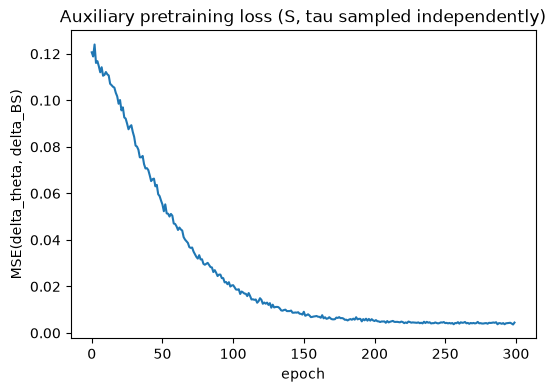

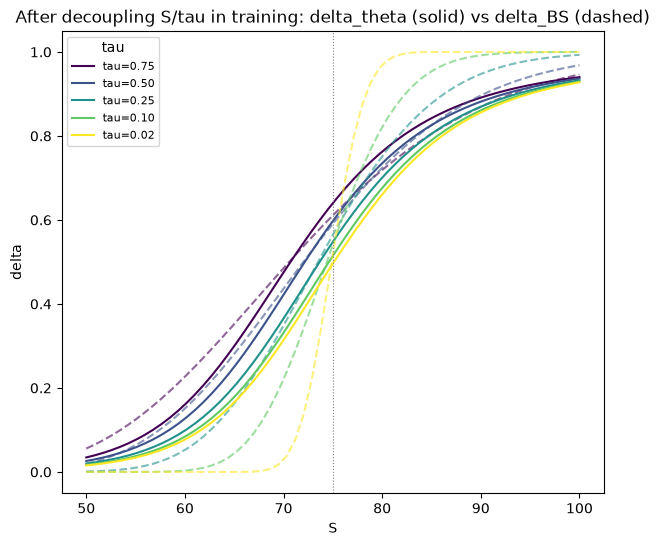

In [17]:
# Quick test: does decoupling S and tau (independently sampled,
# rather than sharing simulate_process's deterministic clock) fix
# the flat-tau-dependence problem? This is NOT the real fix (that's
# restructuring simulate_process itself) -- just a cheap check that
# the diagnosis is right, via a small auxiliary-loss pretraining pass.
# Only valid at c=0, since delta_BS is only the correct target there.

from scipy.stats import norm

def bsm_delta(S_0, K, r, sigma, T):
    """
    # Computes the theoretical delta of a European call under Black-Scholes-Merton given 
    # initial price S_0, strike price K, risk-free rate r, volatility sigma, at time T
    """
    d1 = (np.log(S_0/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)


def extract_delta_theta_grid(model, S_grid, tau_grid, delta_prev_grid=None, K=None, r=None, sigma=None):
    """
    Evaluate the trained policy network as a pure function of (S, tau, delta_prev)
    over a grid, using a fresh hidden state for every query point (no path history).

    S_grid, tau_grid: 1D numpy arrays (need not be the same length)
    delta_prev_grid: optional 2D array matching the (S, tau) mesh; if None,
                      defaults to delta_BS(S, tau) at every grid point.

    Returns: (S_mesh, tau_mesh, delta_theta_mesh) all shape (len(tau_grid), len(S_grid))
    """
    S_mesh, tau_mesh = np.meshgrid(S_grid, tau_grid)  # shape (n_tau, n_S)
    n_tau, n_S = S_mesh.shape
    n = n_tau * n_S

    S_flat = torch.tensor(S_mesh.flatten(), dtype=torch.float32)
    tau_flat = torch.tensor(tau_mesh.flatten(), dtype=torch.float32)

    if delta_prev_grid is None:
        # self-consistent default: delta_prev = delta_BS(S, tau) pointwise
        delta_prev_mesh = bsm_delta(S_mesh, K, r, sigma, tau_mesh)
    else:
        delta_prev_mesh = delta_prev_grid
    delta_prev_flat = torch.tensor(delta_prev_mesh.flatten(), dtype=torch.float32)

    # fresh hidden state sized to the whole grid, evaluated in one batched call
    hidden = model.init_hidden_layer(n)
    with torch.no_grad():
        delta_out, _ = model.step(S_flat, tau_flat, delta_prev_flat, hidden)

    delta_theta_mesh = delta_out.numpy().reshape(n_tau, n_S)
    return S_mesh, tau_mesh, delta_theta_mesh

def sample_random_S_tau_delta(n, S_low=50, S_high=100, tau_low=1e-3, tau_high=T):
    # S and tau drawn INDEPENDENTLY -- this is the whole point: no shared clock
    S = np.random.uniform(S_low, S_high, n)
    tau = np.random.uniform(tau_low, tau_high, n)
    delta_prev = np.random.uniform(0, 1, n)  # arbitrary; c=0 means it shouldn't matter
    return S, tau, delta_prev


def aux_pretrain_step(model, optimizer, n_samples=2000):
    S, tau, delta_prev = sample_random_S_tau_delta(n_samples)
    target = bsm_delta(S, K, R, SIGMA, tau)  # ground truth, valid because c=0

    S_t = torch.tensor(S, dtype=torch.float32)
    tau_t = torch.tensor(tau, dtype=torch.float32)
    delta_t = torch.tensor(delta_prev, dtype=torch.float32)
    target_t = torch.tensor(target, dtype=torch.float32)

    hidden = model.init_hidden_layer(n_samples)  # fresh state -- same reasoning as Test 1 extraction
    pred, _ = model.step(S_t, tau_t, delta_t, hidden)

    loss = ((pred - target_t) ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()


# quick pretraining run, separate optimizer, only touching model params
# (not the CVaR threshold, since this loss has nothing to do with CVaR)
torch.manual_seed(42)
aux_model = LSTMmodel(3, 32, 1, 0.95, UPDATE_INTERVAL)
aux_optimizer = torch.optim.Adam(aux_model.parameters(), lr=0.005)

losses = []
for epoch in range(300):
    l = aux_pretrain_step(aux_model, aux_optimizer)
    losses.append(l)
    if epoch % 50 == 0:
        print(f"epoch {epoch:4d}  aux MSE loss: {l:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("MSE(delta_theta, delta_BS)")
plt.title("Auxiliary pretraining loss (S, tau sampled independently)")
plt.show()

# ---- re-run the same Test 1 grid plot on aux_model to check the fix ----
S_grid = np.linspace(50, 100, 60)
tau_grid = np.array([0.75, 0.5, 0.25, 0.1, 0.02])

S_mesh, tau_mesh, delta_theta_mesh = extract_delta_theta_grid(
    aux_model, S_grid, tau_grid, K=K, r=R, sigma=SIGMA
)
delta_bs_mesh = bsm_delta(S_mesh, K, R, SIGMA, tau_mesh)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
cmap = plt.cm.viridis(np.linspace(0, 1, len(tau_grid)))
for i, tau in enumerate(tau_grid):
    ax.plot(S_grid, delta_bs_mesh[i], '--', color=cmap[i], alpha=0.6)
    ax.plot(S_grid, delta_theta_mesh[i], '-', color=cmap[i], label=f'tau={tau:.2f}')
ax.axvline(K, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel("S")
ax.set_ylabel("delta")
ax.set_title("After decoupling S/tau in training: delta_theta (solid) vs delta_BS (dashed)")
ax.legend(title="tau", fontsize=8)
plt.show()

What we see is this has effectively fixed most of the issue that we encountered earlier. The paths actually match -- at least roughly. So this confirms that the issue is likely to be as we think. 